In [3]:
import pandas as pd

df = pd.read_csv('../data/telco_customer.csv')

print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (7043, 21)


In [6]:
print(df.columns)

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [9]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [11]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

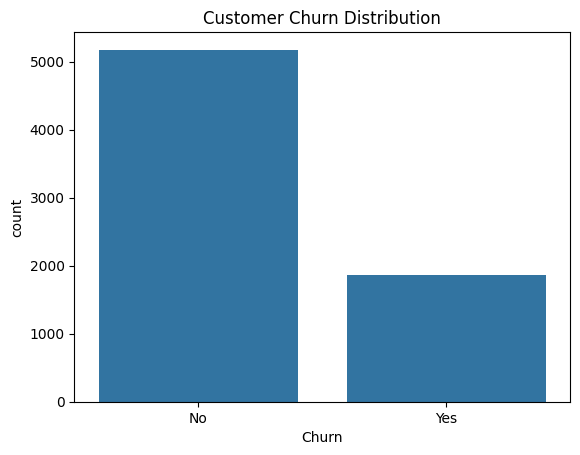

In [15]:
sns.countplot(x='Churn', data=df)
plt.title("Customer Churn Distribution")
plt.show()

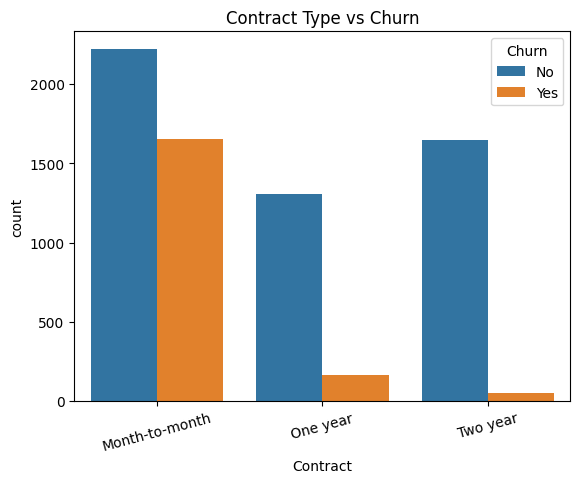

In [17]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Contract Type vs Churn")
plt.xticks(rotation=15)
plt.show()

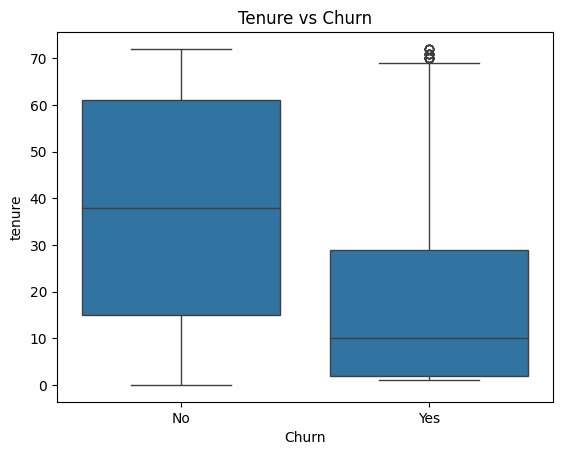

In [19]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()

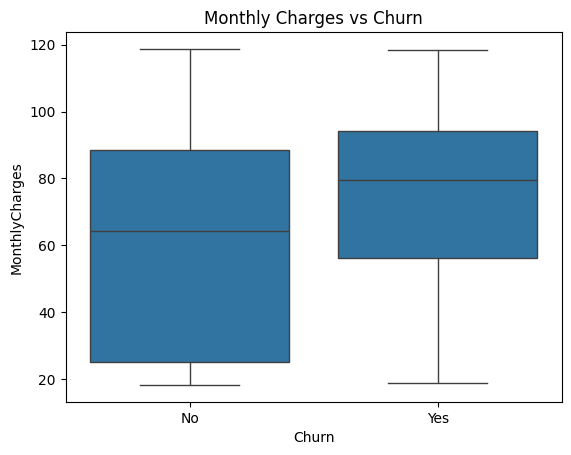

In [20]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

In [21]:
print(df['TotalCharges'].dtype)

str


In [22]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

print(df['TotalCharges'].dtype)

float64


In [23]:
print(df.isnull().sum())

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [24]:
df['TotalCharges'] = df['TotalCharges'].fillna(
    df['TotalCharges'].median()
)

print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [25]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Churn'] = le.fit_transform(df['Churn'])

print(df['Churn'].head())

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64


In [26]:
numeric_df = df.select_dtypes(include=['number'])

numeric_df.corr()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
SeniorCitizen,1.000000,0.016567,0.220173,0.102652,0.150889
tenure,0.016567,1.000000,0.247900,0.825464,-0.352229
MonthlyCharges,0.220173,0.247900,1.000000,0.650864,0.193356
TotalCharges,0.102652,0.825464,0.650864,1.000000,-0.199037
Churn,0.150889,-0.352229,0.193356,-0.199037,1.000000


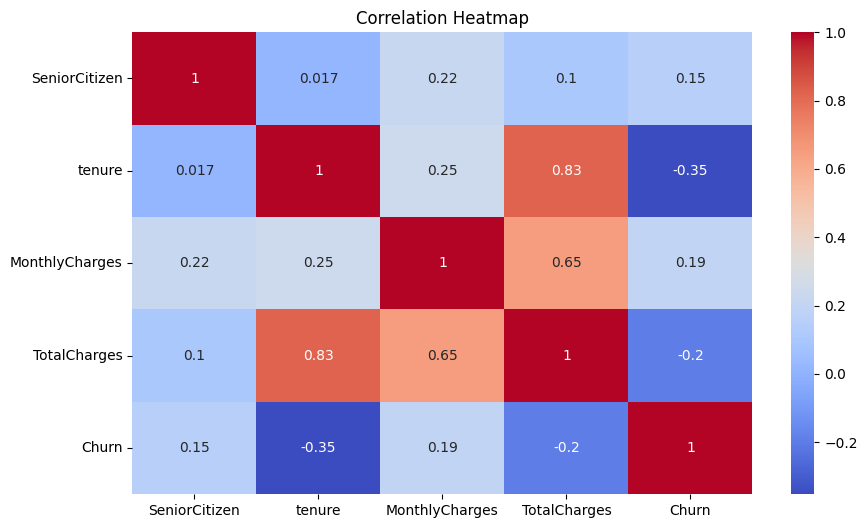

In [27]:
plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

In [28]:
df.to_csv(
    "cleaned_telco_customer.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


# Week 2: Exploratory Data Analysis (EDA)

In this phase, we analyze customer churn patterns and identify business insights that can help improve customer retention.

## 1. Customer Churn Distribution Analysis

Objective:
- Understand the proportion of customers who churned versus those who stayed.
- Establish the baseline churn rate.

In [8]:
# Count churned and retained customers

churn_counts = df['Churn'].value_counts()

print(churn_counts)

Churn
No     5174
Yes    1869
Name: count, dtype: int64


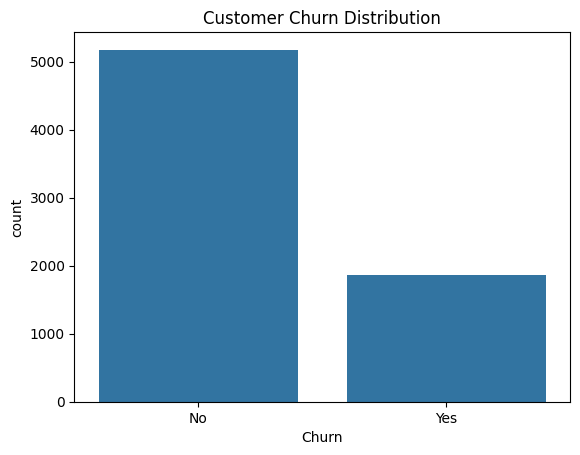

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn', data=df)

plt.title('Customer Churn Distribution')

plt.show()

### Business Insight

The customer churn distribution shows that most customers remain with the company, while a significant portion have churned.

Reducing churn can help the company increase customer retention and improve long-term revenue.

In [10]:
churn_percentage = df['Churn'].value_counts(normalize=True) * 100

print(churn_percentage)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


### Observation

Approximately X% of customers have churned.

This indicates that customer retention is an important business challenge and further analysis is needed to identify the factors influencing churn.

Approximately 26.5% of customers have churned.

## Demographic Analysis

In [11]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

### Gender vs Churn

In [12]:
pd.crosstab(df['gender'], df['Churn'])

Churn,No,Yes
gender,,
Female,2549,939
Male,2625,930


### Business Insight

Female customers have a churn rate of approximately 26.9%, while male customers have a churn rate of approximately 26.2%.

The difference is minimal, suggesting that gender is not a significant factor influencing customer churn. Retention strategies should focus on other factors such as contract type, tenure, and monthly charges.

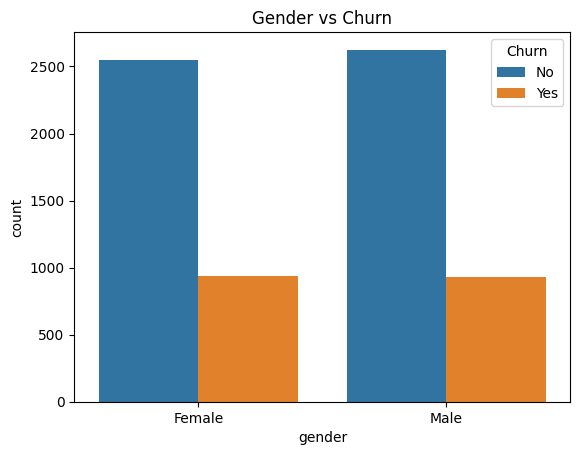

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='gender', hue='Churn', data=df)

plt.title('Gender vs Churn')

plt.show()

### Business Insight

This analysis helps determine whether customer gender has a significant impact on churn behavior.

If churn rates are similar across genders, gender is likely not a major factor influencing customer retention.

### Senior Citizen vs Churn

In [14]:
pd.crosstab(df['SeniorCitizen'], df['Churn'])

Churn,No,Yes
SeniorCitizen,,
0,4508,1393
1,666,476


### Business Insight

Senior citizens show a significantly higher churn rate (approximately 41.7%) compared to non-senior customers (approximately 23.6%).

This suggests that senior customers may face challenges such as pricing concerns, service complexity, or lack of support. The company should consider targeted retention programs and improved customer support for this segment.

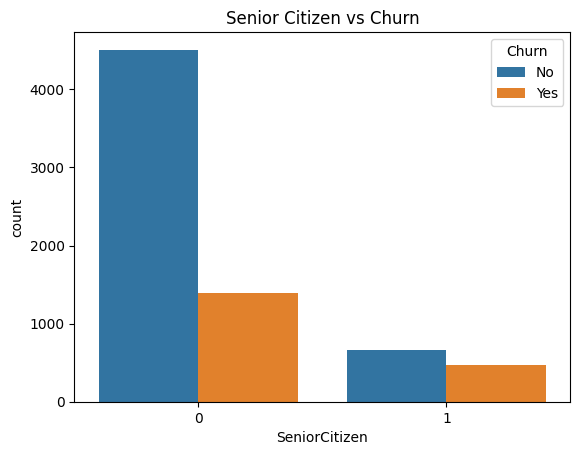

In [15]:
sns.countplot(x='SeniorCitizen', hue='Churn', data=df)

plt.title('Senior Citizen vs Churn')

plt.show()

### Business Insight

This analysis identifies whether senior citizens are more likely to leave the service compared to non-senior customers.

If churn is higher among senior citizens, targeted support and retention programs may be beneficial.

### Partner Status vs Churn

In [16]:
pd.crosstab(df['Partner'], df['Churn'])

Churn,No,Yes
Partner,,
No,2441,1200
Yes,2733,669


### Business Insight

Customers without partners have a significantly higher churn rate (approximately 32.9%) compared to customers with partners (approximately 19.7%).

This suggests that customers with partners may have greater service stability and longer-term commitment. Customers without partners may require targeted retention campaigns and personalized offers to reduce churn.

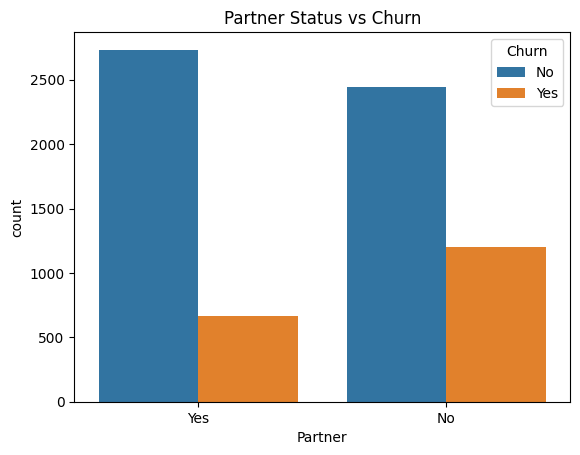

In [17]:
sns.countplot(x='Partner', hue='Churn', data=df)

plt.title('Partner Status vs Churn')

plt.show()

### Business Insight

Customers with partners may exhibit different churn behavior compared to customers without partners.

Understanding this relationship can help improve customer retention strategies.

## Day 9 Findings

### Gender Analysis
Gender has very little impact on customer churn, with both male and female customers showing similar churn rates.

### Senior Citizen Analysis
Senior citizens have a significantly higher churn rate (41.7%) compared to non-senior customers (23.6%).

### Partner Analysis
Customers without partners have a higher churn rate (32.9%) than customers with partners (19.7%).

### Conclusion
Among the demographic variables analyzed, Senior Citizen status and Partner status show a strong relationship with customer churn, while Gender has minimal impact.

## Tenure Analysis

### Average Tenure by Churn Status

In [18]:
df.groupby('Churn')['tenure'].mean()

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

### Business Insight

Customers who churned stayed with the company for an average of only 17.98 months, while retained customers stayed for an average of 37.57 months.

This indicates a strong relationship between customer tenure and churn. Newer customers are significantly more likely to leave the service than long-term customers.

The company should focus on improving customer experience during the first 18–24 months to reduce churn and increase customer lifetime value.

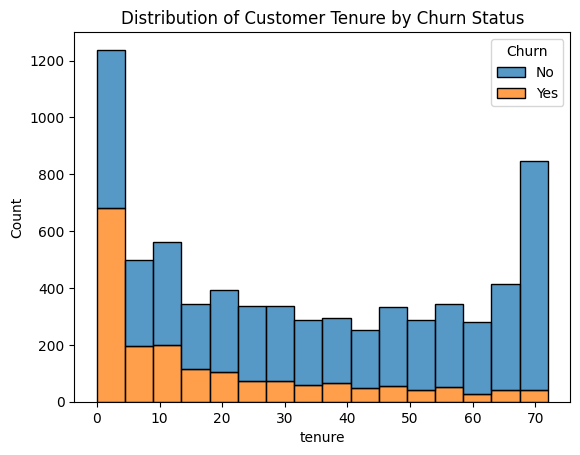

In [20]:
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack')

plt.title('Distribution of Customer Tenure by Churn Status')

plt.show()

## Day 10 Findings

### Key Observation

Customers who churn have a much lower average tenure (17.98 months) compared to retained customers (37.57 months).

### Business Impact

Customer retention efforts should focus on the early stages of the customer lifecycle. Improving onboarding, support, and engagement during the first two years may significantly reduce churn.

### Conclusion

Tenure is a strong predictor of customer churn and should be considered an important feature in future churn prediction models.

## Monthly Charges Analysis

In [21]:
df.groupby('Churn')['MonthlyCharges'].mean()

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

### Business Insight

Customers who churned paid an average monthly charge of $74.44, whereas retained customers paid an average of $61.27.

This suggests that customers with higher monthly charges are more likely to leave the service. The company should investigate whether pricing, perceived value, or competitor offerings are contributing to customer churn.

Special retention offers and loyalty discounts may help reduce churn among high-paying customers.

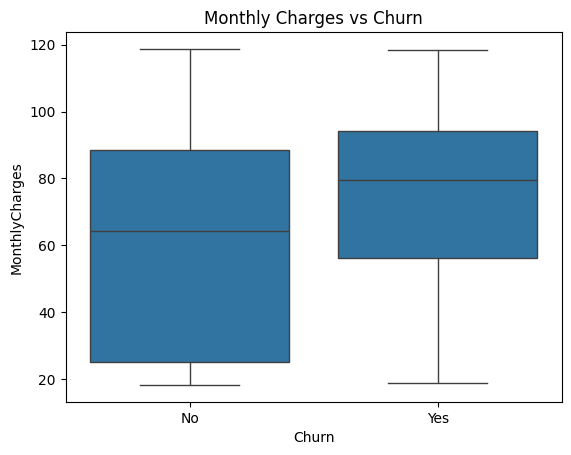

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

plt.title('Monthly Charges vs Churn')
plt.show()

## Day 11 Findings


### Key Observation

Churned customers have significantly higher monthly charges than retained customers.

### Business Impact

Customers paying higher monthly fees may be more sensitive to pricing and service quality.

### Conclusion

Monthly Charges is a strong indicator of customer churn and should be considered an important feature in churn prediction models.

## Contract Type Analysis

In [23]:
pd.crosstab(df['Contract'], df['Churn'])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


### Business Insight

Contract type has a significant impact on customer churn.

Customers on month-to-month contracts have a churn rate of approximately 42.7%, which is substantially higher than customers on one-year contracts (11.3%) and two-year contracts (2.8%).

This suggests that long-term contracts increase customer retention and reduce churn risk. The company should encourage customers to move from month-to-month plans to annual or multi-year plans through discounts and loyalty incentives.

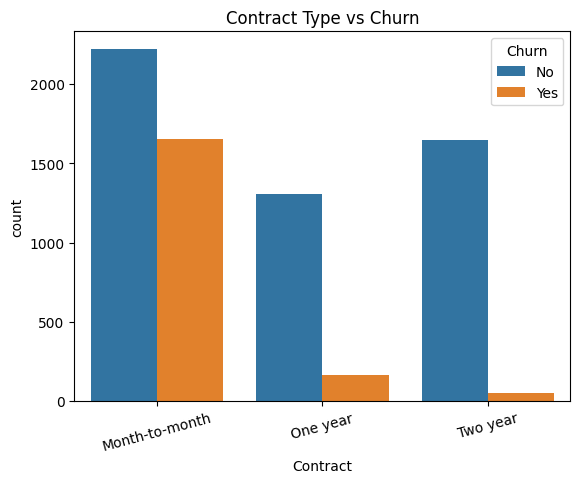

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Contract', hue='Churn', data=df)

plt.title('Contract Type vs Churn')
plt.xticks(rotation=15)
plt.show()

## Day 12 Findings

### Key Observation

Month-to-month customers exhibit the highest churn rate at 42.7%.

### Business Impact

Customers without long-term commitments can easily switch to competitors, making them more likely to churn.

### Recommendation

Offer discounts, loyalty rewards, and contract upgrade incentives to encourage customers to adopt longer contract terms.

### Conclusion

Contract type is one of the strongest predictors of customer churn in this dataset.

## Payment Method Analysis

In [25]:
pd.crosstab(df['PaymentMethod'], df['Churn'])

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1071
Mailed check,1304,308


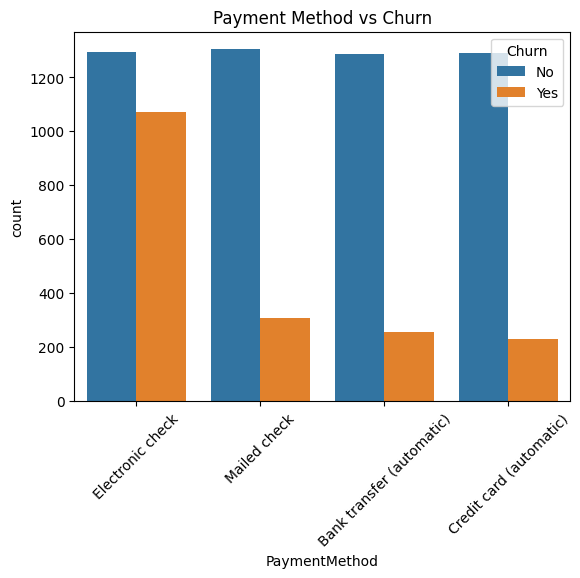

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='PaymentMethod', hue='Churn', data=df)

plt.title('Payment Method vs Churn')
plt.xticks(rotation=45)
plt.show()

### Business Insight

Payment method has a noticeable impact on customer churn.

Customers using Electronic Check have the highest churn rate at approximately 45.3%, significantly higher than customers using automatic payment methods.

Customers using Credit Card (Automatic) and Bank Transfer (Automatic) exhibit much lower churn rates of 15.2% and 16.7%, respectively.

Encouraging customers to adopt automatic payment methods may improve retention and reduce churn.

## Day 13 Findings

### Key Observation

Electronic Check customers show the highest churn rate at 45.3%.

### Business Impact

Manual payment methods may create friction and increase the likelihood of customer attrition.

### Recommendation

Promote automatic payment options through discounts, rewards, and simplified enrollment processes.

### Conclusion

Payment method is an important factor influencing customer churn and should be included in churn prediction models.

## Internet Service Analysis

In [27]:
pd.crosstab(df['InternetService'], df['Churn'])

Churn,No,Yes
InternetService,,
DSL,1962,459
Fiber optic,1799,1297
No,1413,113


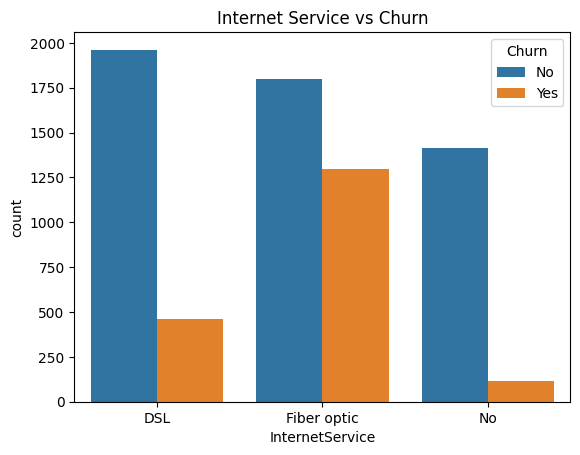

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='InternetService', hue='Churn', data=df)

plt.title('Internet Service vs Churn')
plt.show()

### Business Insight

Internet service type has a strong impact on customer churn.

Customers using Fiber Optic service have the highest churn rate at approximately 41.9%, while DSL customers have a churn rate of 19.0%.

Customers without internet service show the lowest churn rate of only 7.4%.

This suggests that Fiber Optic customers may have higher expectations regarding service quality, pricing, or customer support. The company should investigate service-related issues and improve customer satisfaction among Fiber Optic users.

## Day 14 Findings

### Key Observation

Fiber Optic customers exhibit the highest churn rate at 41.9%.

### Business Impact

A large proportion of churn originates from Fiber Optic customers, making this segment a high-priority retention target.

### Recommendation

Conduct customer satisfaction surveys, improve service reliability, and offer retention incentives for Fiber Optic customers.

### Conclusion

Internet service type is one of the strongest predictors of customer churn and should be included in predictive modeling.